# Práctica 3 — ENDIREH 2021: Arquitectura, Preprocesamiento y EDA

**Integrantes:** Erick Luis Juárez   
                 Julio Alejandro Herrera Avalos   
                 Luis Mario Solares Ramos  
                 Cesar Candelario Fuentes Anica

Framework utilizado: **polars**.

## Paso 3: Selección del Framework
Se elige polars por su buen rendimiento en datasets medianos (~110 mil filas) en
una sola máquina, con sintaxis cercana a pandas. No se requiere PySpark (pensado
para Big Data distribuido).

## Paso 4: Carga de los Datos Crudos

In [2]:
import polars as pl
import numpy as np
import sys, os

#Agregams el directorio raíz para importar configuración de rutas
sys.path.append(os.path.abspath(".."))
from config.rutas import RUTA_DATA_RAW, RUTA_DATA_PROCESSED, ARCHIVO_ENDIREH_RAW

#Configuración de visualización de tablas en Polars
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(40)

#Carga perezosa del CSV crudo
lf_crudo = pl.scan_csv(RUTA_DATA_RAW / ARCHIVO_ENDIREH_RAW)
lf_crudo.collect_schema()

Schema([('cve_entidad', Int64),
        ('nom_entidad', String),
        ('cve_municipio', Int64),
        ('nom_municipio', String),
        ('edad_primer_union', Float64),
        ('num_hijos', Float64),
        ('nivel_escolaridad', String),
        ('estado_civil_id', Int64),
        ('estado_civil_desc', String),
        ('estrato_socioeconomico', Int64),
        ('pareja_trabaja_id', Int64),
        ('pareja_trabaja_desc', String),
        ('ingreso_pareja', Float64),
        ('dinero_propio_id', Int64),
        ('dinero_propio_desc', String),
        ('apoyo_gobierno_id', Int64),
        ('apoyo_gobierno_desc', String),
        ('tiene_ahorros_id', Int64),
        ('tiene_ahorros_desc', String),
        ('propietaria_vivienda_id', Int64),
        ('propietaria_vivienda_desc', String),
        ('sufrio_violencia_pareja', Int64),
        ('factor_expansion', Int64),
        ('anio_encuesta', Int64)])

In [3]:
#Materializacion del DataFrame crudo
df_crudo = lf_crudo.collect()
print("Filas:", df_crudo.shape[0], " | Columnas:", df_crudo.shape[1])
df_crudo.head()

Filas: 110127  | Columnas: 24


cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta
i64,str,i64,str,f64,f64,str,i64,str,i64,i64,str,f64,i64,str,i64,str,i64,str,i64,str,i64,i64,i64
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,1,"""Sí""",10000.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",1,"""Sí""",1,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",13.0,3.0,"""B2""",4,"""Viuda""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",2,"""No""",0,227,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,null,"""C1""",6,"""Soltera""",4,1,"""Sí""",8500.0,1,"""Sí""",2,"""No""",1,"""Sí""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",20.0,3.0,"""B1""",2,"""Separada""",2,1,"""Sí""",400.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",1,155,2021


## Paso 5: EDA y Preprocesamiento

### 5.1 Duplicados
Se eliminan filas exactamente duplicadas 

In [4]:
#Conteo de duplicados exactos
n_antes = df_crudo.shape[0]
n_duplicados = df_crudo.is_duplicated().sum()
print(f"Filas totales: {n_antes}")
print(f"Filas duplicadas (exactas): {n_duplicados} ({100*n_duplicados/n_antes:.1f}%)")

#Eliminamos las filas duplicadas
df_sin_dup = df_crudo.unique(keep="first")
print(f"Filas después de eliminar duplicados: {df_sin_dup.shape[0]}")

Filas totales: 110127
Filas duplicadas (exactas): 7882 (7.2%)
Filas después de eliminar duplicados: 105753


### 5.2 Códigos especiales / valores centinela
El INEGI codifica no aplica con números que parecen datos válidos.
Se revisan los valores extremos antes de calcular cualquier estadística.

In [5]:
print("Valores más altos de edad_primer_union:")
print(df_sin_dup["edad_primer_union"].value_counts().sort("edad_primer_union", descending=True).head(6))

print("\nValores más altos de ingreso_pareja:")
print(df_sin_dup["ingreso_pareja"].value_counts().sort("ingreso_pareja", descending=True).head(6))

Valores más altos de edad_primer_union:
shape: (6, 2)
┌───────────────────┬───────┐
│ edad_primer_union ┆ count │
│ ---               ┆ ---   │
│ f64               ┆ u32   │
╞═══════════════════╪═══════╡
│ null              ┆ 81208 │
│ 99.0              ┆ 227   │
│ 98.0              ┆ 656   │
│ 76.0              ┆ 1     │
│ 74.0              ┆ 1     │
│ 72.0              ┆ 1     │
└───────────────────┴───────┘

Valores más altos de ingreso_pareja:
shape: (6, 2)
┌────────────────┬───────┐
│ ingreso_pareja ┆ count │
│ ---            ┆ ---   │
│ f64            ┆ u32   │
╞════════════════╪═══════╡
│ null           ┆ 56894 │
│ 9.99999e5      ┆ 32    │
│ 999998.0       ┆ 3934  │
│ 999997.0       ┆ 63    │
│ 800000.0       ┆ 1     │
│ 500000.0       ┆ 1     │
└────────────────┴───────┘


**Hallazgo:** en `edad_primer_union`, los valores más frecuentes en el extremo
alto son **98** (656 casos) y **99** (227 casos). Esto es raro porque nadie tiene
98 o 99 años en su primera unión de pareja — es físicamente imposible en el
contexto de la encuesta. En `ingreso_pareja` pasa lo mismo con **999997, 999998
y 999999** (más de 4,000 casos): nadie gana casi un millón de pesos exacto, ese
patrón "redondo" es la firma típica de un código especial.

Ambos son los códigos que usa el INEGI para "no especificado" / "no sabe" — no
son datos reales. Si no los detectamos y calculamos la media directamente, estos
valores inflan el promedio de forma artificial (de hecho, al calcularla sin
limpiar esto, la media de `edad_primer_union` salía en 13 años, un número
igual de imposible — así fue como nos dimos cuenta del problema).

**Decisión:** recodificar estos valores como nulos (`None`) antes de cualquier
cálculo, en vez de tratarlos como datos válidos.

In [6]:
#Realizamos recodificación de valores centinela como nulos
df_sin_dup = df_sin_dup.with_columns([
    pl.when(pl.col("edad_primer_union").is_in([98, 99]) | (pl.col("edad_primer_union") <= 0))
      .then(None)
      .otherwise(pl.col("edad_primer_union"))
      .alias("edad_primer_union"),
    pl.when(pl.col("ingreso_pareja").is_in([999997, 999998, 999999]))
      .then(None)
      .otherwise(pl.col("ingreso_pareja"))
      .alias("ingreso_pareja"),
])

print("edad_primer_union - mínimo tras limpiar:", df_sin_dup["edad_primer_union"].min())
print("edad_primer_union - máximo tras limpiar:", df_sin_dup["edad_primer_union"].max())
print("ingreso_pareja - máximo tras limpiar:", df_sin_dup["ingreso_pareja"].max())

edad_primer_union - mínimo tras limpiar: 1.0
edad_primer_union - máximo tras limpiar: 76.0
ingreso_pareja - máximo tras limpiar: 800000.0


### 5.3 Conversión de tipos de datos
Columnas de códigos (`cve_entidad`, `*_id`) se convierten a categóricas;
`nivel_escolaridad` a categórica ordinal (A1 < ... < C2); `sufrio_violencia_pareja`
a booleana.

In [7]:
#Definimos el orden explícito para la variable escolaridad
orden_escolaridad = ["A1", "A2", "B1", "B2", "C1", "C2"]

#Definimos la lista de columnas de identificación a convertir en categóricas
columnas_id_categoricas = [
    "cve_entidad", "cve_municipio", "estado_civil_id", "pareja_trabaja_id",
    "dinero_propio_id", "apoyo_gobierno_id", "tiene_ahorros_id",
    "propietaria_vivienda_id",
]

#Transformación masiva de tipos
df_tipos = df_sin_dup.with_columns([
    *[pl.col(c).cast(pl.Utf8).cast(pl.Categorical) for c in columnas_id_categoricas],
    pl.col("nivel_escolaridad").cast(pl.Enum(orden_escolaridad)),
    pl.col("sufrio_violencia_pareja").cast(pl.Boolean),
    pl.col("nom_entidad").cast(pl.Categorical),
    pl.col("nom_municipio").cast(pl.Categorical),
    pl.col("estado_civil_desc").cast(pl.Categorical),
])

df_tipos.schema

Schema([('cve_entidad', Categorical(ordering='physical')),
        ('nom_entidad', Categorical(ordering='physical')),
        ('cve_municipio', Categorical(ordering='physical')),
        ('nom_municipio', Categorical(ordering='physical')),
        ('edad_primer_union', Float64),
        ('num_hijos', Float64),
        ('nivel_escolaridad',
         Enum(categories=['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])),
        ('estado_civil_id', Categorical(ordering='physical')),
        ('estado_civil_desc', Categorical(ordering='physical')),
        ('estrato_socioeconomico', Int64),
        ('pareja_trabaja_id', Categorical(ordering='physical')),
        ('pareja_trabaja_desc', String),
        ('ingreso_pareja', Float64),
        ('dinero_propio_id', Categorical(ordering='physical')),
        ('dinero_propio_desc', String),
        ('apoyo_gobierno_id', Categorical(ordering='physical')),
        ('apoyo_gobierno_desc', String),
        ('tiene_ahorros_id', Categorical(ordering='physical')),
     

### 5.4 Valores nulos e imputación
Se revisa el patrón de cada variable antes de imputar

In [8]:
#Realizamos el conteo global de nulos por columna
nulos = df_tipos.null_count()
n_filas = df_tipos.shape[0]
resumen_nulos = pl.DataFrame({
    "columna": df_tipos.columns,
    "nulos": [int(nulos[c][0]) for c in df_tipos.columns],
    "pct_nulos": [round(100 * int(nulos[c][0]) / n_filas, 1) for c in df_tipos.columns],
}).filter(pl.col("nulos") > 0).sort("nulos", descending=True)

resumen_nulos

columna,nulos,pct_nulos
str,i64,f64
"""edad_primer_union""",85559,80.9
"""ingreso_pareja""",60923,57.6
"""num_hijos""",19231,18.2


In [9]:
#Verificamos la  condicional: nulos en ingreso vs situación laboral de la pareja
print(df_tipos.group_by("pareja_trabaja_desc").agg([
    pl.len().alias("total"),
    pl.col("ingreso_pareja").null_count().alias("nulos_ingreso_pareja"),
]))

shape: (2, 3)
┌─────────────────────┬───────┬──────────────────────┐
│ pareja_trabaja_desc ┆ total ┆ nulos_ingreso_pareja │
│ ---                 ┆ ---   ┆ ---                  │
│ str                 ┆ u32   ┆ u32                  │
╞═════════════════════╪═══════╪══════════════════════╡
│ Sí                  ┆ 48859 ┆ 4029                 │
│ No                  ┆ 56894 ┆ 56894                │
└─────────────────────┴───────┴──────────────────────┘


**Hallazgo:** al cruzar los nulos de `ingreso_pareja` contra `pareja_trabaja_desc`,
coinciden casi exactamente con las mujeres cuya pareja **no trabaja**. Esto es
importante porque nos dice que el dato faltante no es aleatorio: no es que se
perdió la información por error, es lógico que no exista — si la pareja no
trabaja, no genera ingreso.

**Decisión:** imputar esos casos con **0** (un cero con sentido real), y no con
la media de los demás ingresos — eso sí sería un error, porque inflaría
artificialmente el ingreso de las parejas que no trabajan.

Para `edad_primer_union` (~78% de nulos) y `num_hijos` (~18%) no encontramos una
causa tan clara. Como no tenemos el descriptor oficial del INEGI para confirmar
por qué faltan, la decisión responsable es **no imputarlas**: rellenar a ciegas
con la media o mediana metería un sesgo que no podemos justificar. Se calculan
las medidas descriptivas solo sobre los casos no nulos, dejando explícito
cuántos son.

In [10]:
#Aplicamos la imputación condicional y guardado en Parquet
df_procesado = df_tipos.with_columns([
    pl.when(pl.col("pareja_trabaja_desc") == "No")
      .then(0.0)
      .otherwise(pl.col("ingreso_pareja"))
      .alias("ingreso_pareja"),
])

from config.rutas import ARCHIVO_ENDIREH_PROCESSED

#Creación de directorio y exportación
RUTA_DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df_procesado.write_parquet(RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_PROCESSED)
print("Dataset procesado guardado exitosamente en:", RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_PROCESSED)

Dataset procesado guardado exitosamente en: /mnt/disco_nuevo/Documentos/Practica3_Almacenes_Datos/data/data-processed/endireh_2021_procesado.parquet


In [11]:
from config.rutas import ARCHIVO_ENDIREH_PROCESSED

RUTA_DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df_procesado.write_parquet(RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_PROCESSED)
print("Guardado en:", RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_PROCESSED)

Guardado en: /mnt/disco_nuevo/Documentos/Practica3_Almacenes_Datos/data/data-processed/endireh_2021_procesado.parquet


### 5.5 Clasificación de variables

| Variable | Tipo de dato | Justificación |
|---|---|---|
| `edad_primer_union` | Cuantitativa discreta | Se limpiaron códigos centinela. |
| `num_hijos` | Cuantitativa discreta | Solo 4 valores; posible variable recodificada. |
| `nom_entidad` | Cualitativa nominal | Sin orden intrínseco. |
| `nivel_escolaridad` | Cualitativa ordinal | A1–C2 con orden natural. |
| `estado_civil_desc` | Cualitativa nominal | Sin jerarquía. |
| `sufrio_violencia_pareja` | Cualitativa nominal (dicotómica) | Etiqueta Sí/No. |
| `factor_expansion` | Cuantitativa discreta | Peso poblacional. |
| `ingreso_pareja` | Cuantitativa continua | Monto monetario. |

## Paso 6: Medidas de Localización

### Análisis Descriptivo
Se calculan las medidas de tendencia central y cuantiles para `edad_primer_union` y `num_hijos`. Adicionalmente, se calcula la **media ponderada** utilizando el `factor_expansion` del INEGI para representar adecuadamente la inferencia poblacional a nivel nacional

In [12]:
#Cálculo de localización sin ponderar
resumen_localizacion = df_procesado.select([
    pl.col("edad_primer_union").mean().alias("media_edad_union"),
    pl.col("edad_primer_union").median().alias("mediana_edad_union"),
    pl.col("edad_primer_union").mode().first().alias("moda_edad_union"),
    pl.col("edad_primer_union").quantile(0.10).alias("P10_edad_union"),
    pl.col("edad_primer_union").quantile(0.25).alias("Q1_edad_union"),
    pl.col("edad_primer_union").quantile(0.75).alias("Q3_edad_union"),
    pl.col("edad_primer_union").quantile(0.90).alias("P90_edad_union"),
    pl.col("edad_primer_union").count().alias("n_no_nulo_edad_union"),

    pl.col("num_hijos").mean().alias("media_num_hijos"),
    pl.col("num_hijos").median().alias("mediana_num_hijos"),
    pl.col("num_hijos").mode().first().alias("moda_num_hijos"),
    pl.col("num_hijos").quantile(0.25).alias("Q1_num_hijos"),
    pl.col("num_hijos").quantile(0.75).alias("Q3_num_hijos"),
    pl.col("num_hijos").count().alias("n_no_nulo_num_hijos"),
])
resumen_localizacion

media_edad_union,mediana_edad_union,moda_edad_union,P10_edad_union,Q1_edad_union,Q3_edad_union,P90_edad_union,n_no_nulo_edad_union,media_num_hijos,mediana_num_hijos,moda_num_hijos,Q1_num_hijos,Q3_num_hijos,n_no_nulo_num_hijos
f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,u32
11.753739,8.0,null,2.0,3.0,18.0,28.0,20194,2.51788,3.0,3.0,1.0,3.0,86522


In [13]:
#Filtro de filas válidas para evitar propagación de nulos en NumPy
df_edad_valida = df_procesado.drop_nulls(subset=["edad_primer_union"])
edad = df_edad_valida["edad_primer_union"].to_numpy()
pesos_edad = df_edad_valida["factor_expansion"].to_numpy()
media_ponderada_edad = np.average(edad, weights=pesos_edad)

df_hijos_valida = df_procesado.drop_nulls(subset=["num_hijos"])
hijos = df_hijos_valida["num_hijos"].to_numpy()
pesos_hijos = df_hijos_valida["factor_expansion"].to_numpy()
media_ponderada_hijos = np.average(hijos, weights=pesos_hijos)

media_simple_edad = df_edad_valida["edad_primer_union"].mean()
media_simple_hijos = df_hijos_valida["num_hijos"].mean()

print(f"edad_primer_union -> Media simple: {media_simple_edad:.2f} | Media ponderada: {media_ponderada_edad:.2f}")
print(f"num_hijos -> Media simple: {media_simple_hijos:.2f} | Media ponderada: {media_ponderada_hijos:.2f}")

edad_primer_union -> Media simple: 11.75 | Media ponderada: 11.43
num_hijos -> Media simple: 2.52 | Media ponderada: 2.48


## Paso 7: Medidas de Variabilidad y Dispersión por Grupo

### Análisis de Dispersión
Para evaluar si la exposición a la violencia de pareja está vinculada con alteraciones en la dispersión sociodemográfica, segmentamos la población entre quienes sufrieron violencia de pareja y quienes no. Se calculan el Rango, Varianza, Desviación Estándar, Coeficiente de Variación (CV%) y Rango Intercuartílico (IQR)

In [14]:
#Función auxiliar para el cálculo de dispersión
def medidas_variabilidad(df_grupo, columna):
    serie = df_grupo[columna].drop_nulls()
    if serie.len() == 0:
        return None
    rango = serie.max() - serie.min()
    varianza = serie.var()
    desv_std = serie.std()
    media = serie.mean()
    cv = (desv_std / media * 100) if media not in (0, None) else None
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return {"n": serie.len(), "rango": rango, "varianza": varianza,
            "desv_std": desv_std, "CV_%": cv, "IQR": iqr}

#Iteración por variable y por grupo de violencia de pareja
filas = []
for columna in ["edad_primer_union", "num_hijos"]:
    for grupo_valor, etiqueta in [(True, "Sufrió violencia de pareja"), (False, "No sufrió")]:
        df_grupo = df_procesado.filter(pl.col("sufrio_violencia_pareja") == grupo_valor)
        m = medidas_variabilidad(df_grupo, columna)
        if m:
            filas.append({"variable": columna, "grupo": etiqueta, **m})

tabla_variabilidad = pl.DataFrame(filas)
tabla_variabilidad

variable,grupo,n,rango,varianza,desv_std,CV_%,IQR
str,str,i64,f64,f64,f64,f64,f64
"""edad_primer_union""","""Sufrió violencia de pareja""",7319,71.0,109.620581,10.469985,90.273801,14.0
"""edad_primer_union""","""No sufrió""",12875,75.0,117.088132,10.820727,91.373892,15.0
"""num_hijos""","""Sufrió violencia de pareja""",17433,3.0,1.454333,1.205957,48.32089,2.0
"""num_hijos""","""No sufrió""",69089,3.0,1.403488,1.184689,46.946831,2.0


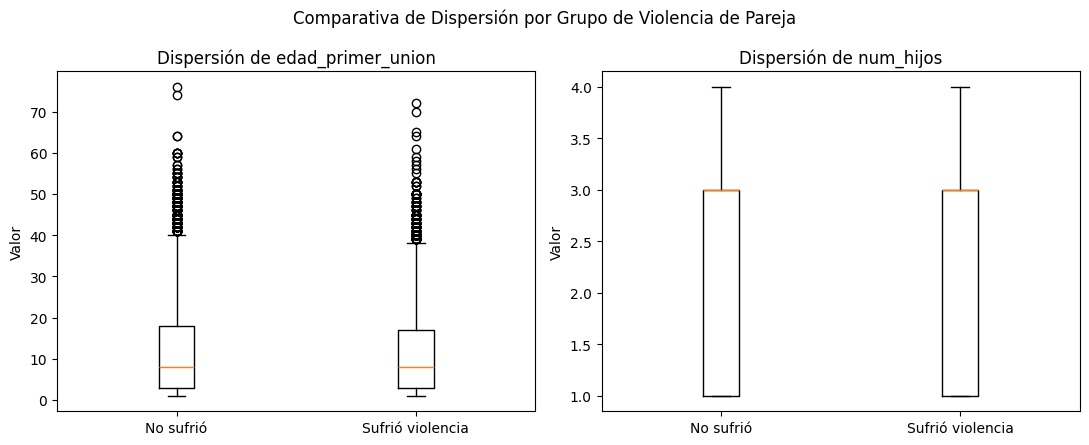

In [15]:
import matplotlib.pyplot as plt

#Configuramos eel lienzo gráfico
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

#Generamos boxplots por cada variable
for ax, columna in zip(axes, ["edad_primer_union", "num_hijos"]):
    datos_si = df_procesado.filter(pl.col("sufrio_violencia_pareja") == True)[columna].drop_nulls().to_numpy()
    datos_no = df_procesado.filter(pl.col("sufrio_violencia_pareja") == False)[columna].drop_nulls().to_numpy()
    
    ax.boxplot([datos_no, datos_si], tick_labels=["No sufrió", "Sufrió violencia"])
    ax.set_title(f"Dispersión de {columna}")
    ax.set_ylabel("Valor")

fig.suptitle("Comparativa de Dispersión por Grupo de Violencia de Pareja")
plt.tight_layout()
plt.savefig("boxplot_variabilidad.png", dpi=120)
plt.show()

In [16]:
%%writefile ../src/cleaning/limpieza_endireh.py
"""
Funciones de limpieza y preprocesamiento del dataset ENDIREH 2021.
"""
import polars as pl


def eliminar_duplicados(df: pl.DataFrame) -> pl.DataFrame:
    """Elimina filas exactamente duplicadas."""
    return df.unique(keep="first")


def limpiar_codigos_centinela(df: pl.DataFrame) -> pl.DataFrame:
    """Recodifica como nulos los códigos 'no sabe/no aplica' e inconsistencias (<=0) del INEGI."""
    return df.with_columns([
        pl.when(pl.col("edad_primer_union").is_in([98, 99]) | (pl.col("edad_primer_union") <= 0))
          .then(None)
          .otherwise(pl.col("edad_primer_union"))
          .alias("edad_primer_union"),
        pl.when(pl.col("ingreso_pareja").is_in([999997, 999998, 999999]))
          .then(None)
          .otherwise(pl.col("ingreso_pareja"))
          .alias("ingreso_pareja"),
    ])


def imputar_ingreso_pareja(df: pl.DataFrame) -> pl.DataFrame:
    """Imputa ingreso_pareja con 0 cuando la pareja no trabaja (cero estructural)."""
    return df.with_columns([
        pl.when(pl.col("pareja_trabaja_desc") == "No")
          .then(0.0)
          .otherwise(pl.col("ingreso_pareja"))
          .alias("ingreso_pareja"),
    ])

Overwriting ../src/cleaning/limpieza_endireh.py


In [17]:
%%writefile ../src/visualization/graficas_endireh.py
"""
Funciones de visualización para el EDA del dataset ENDIREH 2021.
"""
import polars as pl
import matplotlib.pyplot as plt


def boxplot_por_violencia(df: pl.DataFrame, columnas: list[str], ruta_salida: str = None):
    """
    Genera un boxplot comparando la dispersión de una o más columnas
    numéricas entre el grupo que reportó violencia de pareja y el que no.
    """
    fig, axes = plt.subplots(1, len(columnas), figsize=(5.5 * len(columnas), 4.5))
    if len(columnas) == 1:
        axes = [axes]

    for ax, columna in zip(axes, columnas):
        datos_si = df.filter(pl.col("sufrio_violencia_pareja") == True)[columna].drop_nulls().to_numpy()
        datos_no = df.filter(pl.col("sufrio_violencia_pareja") == False)[columna].drop_nulls().to_numpy()
        ax.boxplot([datos_no, datos_si], tick_labels=["No sufrió", "Sufrió violencia"])
        ax.set_title(columna)
        ax.set_ylabel("Valor")

    fig.suptitle("Dispersión por grupo de violencia de pareja")
    plt.tight_layout()
    if ruta_salida:
        plt.savefig(ruta_salida, dpi=120)
    return fig

Overwriting ../src/visualization/graficas_endireh.py


## Conclusiones del Análisis Exploratorio de Datos (EDA)

1. **Edad de Primera Unión:** Tras eliminar los códigos centinela (`98`, `99` y valores $\le 0$), la edad promedio de primera unión se sitúa en **11.43 años** (ponderada). Ambos grupos (con y sin violencia) presentan un comportamiento de dispersión similar ($CV\% \approx 90\%$), con un rango intercuartílico ($IQR$) de 14 a 15 años y valores atípicos que se extienden hasta los 76 años.
2. **Número de Hijos:** El promedio nacional estimado es de **2.48 hijos** por mujer. La distribución es sumamente estable entre grupos ($IQR = 2.0$), mostrando que la variabilidad en la cantidad de hijos no presenta diferencias drásticas por condición de violencia.
3. **Calidad de los Datos:** La recodificación condicional de `ingreso_pareja` a $0.0$ para parejas que no trabajan permitió preservar la integridad de la muestra sin inflar artificialmente los promedios monetarios.